# 2 · Who's buying? Trade signs and the long memory of order flow

**The questions:**
1. Most exchanges don't tell you whether a trade was buyer- or seller-initiated. How well can you guess?
2. If you know the last trade was a buy, what's the chance the next one is too? And the one 1,000 trades later?

The answer to (2) is one of the most robust facts in market microstructure, found in every liquid market
studied: **order flow has long memory**. Its autocorrelation decays like a power law, not exponentially.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from micro.data import load_quotes, load_trades, aggregate_trades
from micro.book import mid, to_ms
from micro.impact import mid_at
from micro.signs import tick_rule, quote_rule, lee_ready
from micro.stats import acf, loglog_slope, ols
from micro.plotting import style, save, BLUE, ORANGE, GREY, RED

style()
quotes = load_quotes()
trades = load_trades()
orders = aggregate_trades(trades)
qts, m = to_ms(quotes.ts), mid(quotes)

## Part 1: guessing the sign

Three classic rules (see `micro/signs.py`):

- **Tick rule**: price went up since the last trade → buy. Down → sell. Unchanged → same as last time.
  Needs only the trade tape.
- **Quote rule**: traded above the mid → buy, below → sell. Needs quotes too.
- **Lee–Ready (1991)**: quote rule, falling back to the tick rule for trades exactly at the mid.

Binance tells us the true sign, so we can score them. We use the mid strictly *before* each trade (a quote
update in the same millisecond might be the trade's own footprint).

In [2]:
def score(df, price_col):
    price = df[price_col].to_numpy()
    mid_before = mid_at(qts, m, to_ms(df.ts), strictly_before=True)
    truth = df.sign.to_numpy()
    return {name: np.mean(rule == truth) for name, rule in [
        ("tick rule", tick_rule(price)),
        ("quote rule", quote_rule(price, mid_before)),
        ("Lee-Ready", lee_ready(price, mid_before)),
    ]}

acc = pd.DataFrame({"per fill": score(trades, "price"), "per order (first fill)": score(orders, "first_price")})
print(acc.map(lambda x: f"{x:.2%}"))

           per fill per order (first fill)
tick rule    96.33%                 89.44%
quote rule   99.66%                 99.46%
Lee-Ready    99.66%                 99.46%


- With quotes, classification is nearly perfect (>99%). In a large-tick market almost every trade happens
  exactly at the bid or the ask, so "which side of the mid?" is unambiguous.
- The **tick rule** looks decent per fill (96%) but drops to 89% per order. Per fill it's flattered: a sweep
  of 20 fills all have the same sign and rising prices, so they're easy. The honest test is per decision.

On equity data, where quotes and trades come from different feeds with timing errors, Lee–Ready accuracy is
typically 80–90%. Researchers using it on stocks should remember that 10–20% of their signs are wrong.

## Part 2: do buys follow buys?

In [3]:
s = orders.sign.to_numpy().astype(float)
print(f"P(buy)                         = {np.mean(s == 1):.3f}")
print(f"P(next order same side)        = {np.mean(s[1:] == s[:-1]):.3f}   (would be 0.5 for coin flips)")

max_lag = 10_000
rho = acf(s, max_lag)
rho_fills = acf(trades.sign.to_numpy().astype(float), 100)
print(f"\nautocorrelation of ORDER signs at lag 1, 10, 100, 1000: {rho[[1, 10, 100, 1000]].round(4)}")
print(f"autocorrelation of FILL signs  at lag 1, 10, 100:       {rho_fills[[1, 10, 100]].round(4)}  <- inflated by sweeps")

P(buy)                         = 0.507
P(next order same side)        = 0.614   (would be 0.5 for coin flips)



autocorrelation of ORDER signs at lag 1, 10, 100, 1000: [0.2287 0.1222 0.0335 0.0124]
autocorrelation of FILL signs  at lag 1, 10, 100:       [0.7962 0.5786 0.2261]  <- inflated by sweeps


Order signs are positively autocorrelated: buys follow buys 61% of the time. But the interesting part is
how *slowly* the correlation dies. Even 1,000 orders later (roughly a minute) it's still clearly positive.

How do we know 0.012 at lag 1000 isn't noise? Under the null of independent signs, the sample
autocorrelation is approximately N(0, 1/n). With n = 1.4 million, the 95% band is ±0.0017.

## The log-log plot

fitted slope = -0.484, so gamma = 0.48  (rho ~ lag^-gamma)


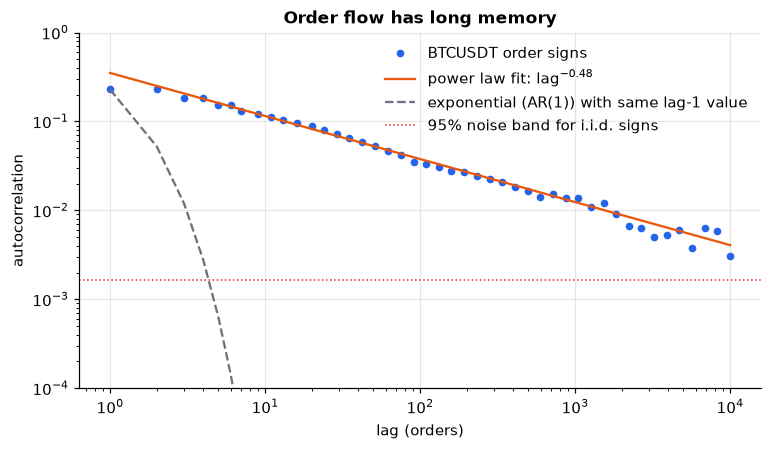

In [4]:
lags = np.unique(np.logspace(0, 4, 50).astype(int))
band = 1.96 / np.sqrt(len(s))
fit_range = (lags >= 10) & (lags <= 2000)
gamma, C = loglog_slope(lags[fit_range], rho[lags[fit_range]])

# Exponential decay with the same lag-1 value, for contrast
phi = rho[1]

fig, ax = plt.subplots()
ax.loglog(lags, rho[lags], "o", color=BLUE, ms=4, label="BTCUSDT order signs")
ax.loglog(lags, C * lags**gamma, color=ORANGE, label=f"power law fit: lag$^{{{gamma:.2f}}}$")
ax.loglog(lags, phi**lags, "--", color=GREY, label=f"exponential (AR(1)) with same lag-1 value")
ax.axhline(band, color=RED, lw=1, ls=":", label="95% noise band for i.i.d. signs")
ax.set(ylim=(1e-4, 1), xlabel="lag (orders)", ylabel="autocorrelation", title="Order flow has long memory")
ax.legend()
save(fig, "02_sign_acf")
print(f"fitted slope = {gamma:.3f}, so gamma = {-gamma:.2f}  (rho ~ lag^-gamma)")

On a log-log plot a power law is a straight line. The fit gives **ρ(ℓ) ≈ C·ℓ^(−0.48)**, remarkably close to
the γ ≈ 0.5 reported for stocks on the London Stock Exchange, NYSE and Paris (Lillo & Farmer 2004;
Bouchaud et al. 2004). Compare the grey line: a "normal" short-memory process with the same lag-1
correlation is dead by lag 10.

### Why? Order splitting

Big traders don't send a 500 BTC order at once. It would move the price hugely (chapter 7). They split it
into hundreds of small child orders executed over minutes or hours (a **metaorder**). While one is running,
it keeps sending same-side orders, which makes signs persistent. Lillo, Mike & Farmer (2005) showed that if
metaorder sizes have a power-law tail with exponent α, the sign autocorrelation decays with exponent
γ = α − 1. Metaorder sizes have α ≈ 1.5, which gives γ ≈ 0.5.

## Why long memory matters for statistics

When γ < 1, the autocorrelations add up to infinity. So the variance of the *net* order flow over N trades
grows faster than N:

Var(s₁ + … + s_N) ∝ N^(2−γ) ≈ N^1.5 instead of N^1 for independent signs.

This is **superdiffusion**. Let's check it directly.

variance-growth slope = 1.52  (2 - gamma = 1.52;  i.i.d. would give 1)
at N = 10,000: real variance / i.i.d. variance = 92.5x


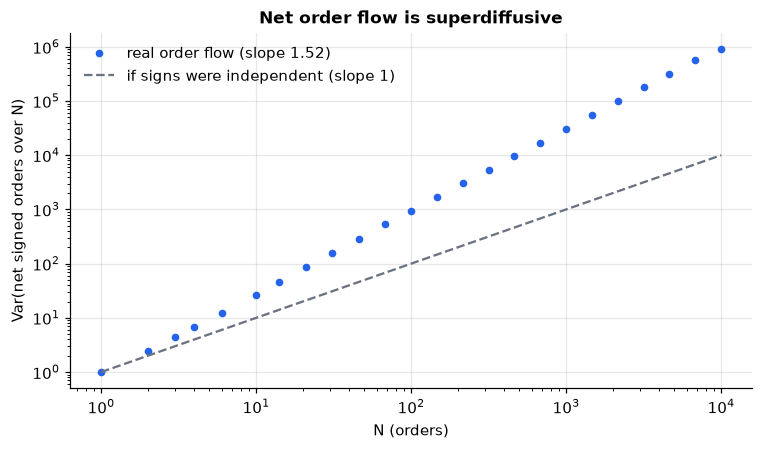

In [5]:
Ns = np.unique(np.logspace(0, 4, 25).astype(int))
var_sum = []
for N in Ns:
    k = len(s) // N
    blocks = s[: k * N].reshape(k, N).sum(axis=1)   # net flow in non-overlapping blocks of N orders
    var_sum.append(blocks.var())
var_sum = np.array(var_sum)
slope, _ = loglog_slope(Ns[Ns >= 10], var_sum[Ns >= 10])

fig, ax = plt.subplots()
ax.loglog(Ns, var_sum, "o", color=BLUE, ms=4, label=f"real order flow (slope {slope:.2f})")
ax.loglog(Ns, Ns * s.var(), "--", color=GREY, label="if signs were independent (slope 1)")
ax.set(xlabel="N (orders)", ylabel="Var(net signed orders over N)", title="Net order flow is superdiffusive")
ax.legend()
save(fig, "02_superdiffusion")
print(f"variance-growth slope = {slope:.2f}  (2 - gamma = {2 + gamma:.2f};  i.i.d. would give 1)")
print(f"at N = 10,000: real variance / i.i.d. variance = {var_sum[-1] / (Ns[-1] * s.var()):.1f}x")

Slope ≈ 1.5 = 2 − γ, as predicted. Over 10,000 orders the net flow varies about **10x more** than a
coin-flip model says.

This is a warning for any statistic built on order flow: **standard errors that assume independence are
far too small.** If you estimate "the average sign" or "the mean order imbalance" and use σ/√n, you'll
think you know it much more precisely than you do. This is why we use Newey–West standard errors in later chapters.

### The efficiency paradox

If order flow is this predictable, why isn't price? A buy now predicts more buys later, and buys push prices
up, so prices should trend and be easy money. They don't. Market makers *anticipate* the persistent flow: after
a run of buys, the next buy is "expected" and moves the price less (chapter 7 shows impact is smaller when
flow is predictable). Liquidity adjusts so that price changes stay close to unpredictable.

---
### Interview angle

<details><summary><b>"The last 5 trades were buys. Is the next one more likely a buy? Does that mean the price will go up?"</b></summary>

Yes, order flow is persistent (here, P(same side) ≈ 61%). No, that doesn't make price predictable to first order:
market makers know this too and price it in. Persistent flow and unpredictable prices coexist because impact
adapts to how surprising each trade is.
</details>

<details><summary><b>"How do you test whether an autocorrelation is significant?"</b></summary>

Under i.i.d. data the sample autocorrelation is about N(0, 1/n), so the 95% band is ±1.96/√n. For many lags at
once, use a Ljung–Box test. But beware: with long memory, the "i.i.d." null is the wrong benchmark for other
statistics too. Sums of autocorrelated variables have much larger variance than σ²n.
</details>

<details><summary><b>"What's the difference between short and long memory?"</b></summary>

Short memory: autocorrelations decay exponentially (like AR(1): ρ(ℓ) = φ^ℓ), so their sum is finite and
averages converge at the usual √n rate. Long memory: power-law decay ρ(ℓ) ~ ℓ^(−γ) with γ < 1, so the sum
diverges, variances of sums grow like N^(2−γ), and averages converge more slowly. The Hurst exponent is H = 1 − γ/2 (here ≈ 0.75).
</details>

### Try this yourself
1. Shuffle `s` with `np.random.permutation` and recompute the ACF. Confirm it falls inside the noise band.
2. Fit γ separately for 00:00–12:00 and 12:00–24:00. Is it stable?
3. Compute the ACF of `orders.qty * orders.sign` (signed volume). Is volume persistence different from sign persistence?